In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Importing libraries
import sys
import keras
import cv2
import numpy
import matplotlib
import skimage
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D
from keras.optimizers import Adam
from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import random
import cv2
import numpy as np
import math
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

2025-11-13 18:58:00.206051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763060280.426399      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763060280.495003      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/patches/kaggle/working/patches/t37_106.png
/kaggle/input/patches/kaggle/working/patches/t53_190.png
/kaggle/input/patches/kaggle/working/patches/tt3_348.png
/kaggle/input/patches/kaggle/working/patches/tt23_284.png
/kaggle/input/patches/kaggle/working/patches/t58_25.png
/kaggle/input/patches/kaggle/working/patches/t46_290.png
/kaggle/input/patches/kaggle/working/patches/t46_314.png
/kaggle/input/patches/kaggle/working/patches/t66_238.png
/kaggle/input/patches/kaggle/working/patches/t11_45.png
/kaggle/input/patches/kaggle/working/patches/tt5_259.png
/kaggle/input/patches/kaggle/working/patches/tt6_115.png
/kaggle/input/patches/kaggle/working/patches/t15_51.png
/kaggle/input/patches/kaggle/working/patches/t46_420.png
/kaggle/input/patches/kaggle/working/patches/tt6_532.png
/kaggle/input/patches/kaggle/working/patches/tt9_564.png
/kaggle/input/patches/kaggle/working/patches/t40_98.png
/kaggle/input/patches/kaggle/working/patches/tt2_314.png
/kaggle/input/patches/kaggle/worki

In [6]:
def psnr(target, ref):
    target_data = target.astype(float)
    ref_data = ref.astype(float)
    diff = ref_data - target_data
    diff = diff.flatten('C')
    rmse = math.sqrt(np.mean(diff ** 2.))
    return 20 * math.log10(255. / rmse)
    

def mse(target, ref):
    err = np.sum((target.astype('float') - ref.astype('float')) ** 2)
    err /= float(target.shape[0] * target.shape[1])
    return err

def compare_images(target, ref):
    scores = []
    scores.append(psnr(target, ref))
    scores.append(mse(target, ref))
    scores.append(ssim(target, ref, multichannel=True))
    return scores

def modcrop(img, scale):
    tmpsz = img.shape
    sz = tmpsz[0:2]
    sz = sz - np.mod(sz, scale)
    img = img[0:sz[0], 0:sz[1]]
    return img

def shave(image, border):
    img = image[border: -border, border: -border]
    return img

In [3]:
def create_functional_model():
    inputs = Input(shape=(None, None, 1))

    x = Conv2D(filters=64, kernel_size=(9, 9), kernel_initializer='glorot_uniform',
             activation='relu', padding='valid', use_bias=True,
             name='conv1')(inputs)

    x = Conv2D(filters=32, kernel_size=(1, 1), kernel_initializer='glorot_uniform',
             activation='relu', padding='same', use_bias=True,
             name='conv2')(x)
    outputs = Conv2D(filters=1, kernel_size=(5, 5), kernel_initializer='glorot_uniform',
             activation='relu', padding='valid', use_bias=True,
             name='conv3')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

srcnn_model = create_functional_model()
optimizer = Adam(learning_rate=0.0001)

loss_fn = tf.keras.losses.MeanAbsoluteError()

I0000 00:00:1763060397.132528      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763060397.133274      39 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
def load_training_data(patches_dir, factor):

    border = 6

    X_data = []
    Y_data = []

    count = 0
    print(f"Loading patches from {patches_dir}...")

    for file in os.listdir(patches_dir):
        try:
            ref = cv2.imread(os.path.join(patches_dir, file))

            ref_y = cv2.cvtColor(ref, cv2.COLOR_BGR2YCrCb)[:, :, 0]

            Y_patch = shave(ref_y, border)
            # Y_patch = ref

            Y_data.append(Y_patch.astype(float) / 255.0)

            h, w, _ = ref.shape
            new_height = int(h / factor)
            new_width = int(w / factor)

            degraded = cv2.resize(ref, (new_width, new_height), interpolation = cv2.INTER_CUBIC)
            degraded = cv2.resize(degraded, (w, h), interpolation = cv2.INTER_CUBIC)

            degraded_y = cv2.cvtColor(degraded, cv2.COLOR_BGR2YCrCb)[:, :, 0]

            X_data.append(degraded_y.astype(float) / 255.0)

            count += 1

        except Exception as e:
            print(f'ERROR for file {file}: {e}')
            pass

    print(f"Successfully loaded {count} patches.")

    X_train = np.array(X_data)
    Y_train = np.array(Y_data)

    X_train = np.expand_dims(X_train, axis=-1)
    Y_train = np.expand_dims(Y_train, axis=-1)

    print("Data loading complete.")
    return X_train, Y_train

def test_image(image_path, model, scale):

    ref = cv2.imread(image_path)
    ref = modcrop(ref, scale)

    h, w, _ = ref.shape
    new_height = int(h / scale)
    new_width = int(w / scale)
    
    degraded = cv2.resize(ref, (new_width, new_height), interpolation=cv2.INTER_CUBIC)
    degraded = cv2.resize(degraded, (w, h), interpolation=cv2.INTER_CUBIC)

    degraded_y = (cv2.cvtColor(degraded, cv2.COLOR_BGR2YCrCb)[:, :, 0]).astype(float) / 255.0

    Y = np.expand_dims(degraded_y, axis=0)
    Y = np.expand_dims(Y, axis=-1)

    pre = model.predict(Y, verbose=0)

    pre = pre.squeeze() * 255.0
    pre = np.clip(pre, 0, 255)

    border = 6
    ref_shaved = shave(cv2.cvtColor(ref, cv2.COLOR_BGR2YCrCb)[:, :, 0], border)

    degraded_shaved = shave(cv2.cvtColor(degraded, cv2.COLOR_BGR2YCrCb)[:, :, 0], border)

    psnr_degraded = psnr(degraded_shaved, ref_shaved)
    psnr_model = psnr(pre, ref_shaved)

    return psnr_degraded, psnr_model


In [7]:
SCALE = 2
PATCHES_DIR = '/kaggle/input/patches/kaggle/working/patches'

X_train, Y_train = load_training_data(PATCHES_DIR, SCALE)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")

srcnn_model.summary()

@tf.function
def train_step(x, y):
    with tf.GradientTape(persistent=True) as tape:
        
        y_pred = srcnn_model(x, training=True)
        
        loss = loss_fn(y, y_pred)

        grads = tape.gradient(loss, srcnn_model.trainable_variables)
    
        optimizer.apply_gradients(zip(grads, srcnn_model.trainable_variables))

    del tape

    return loss


EPOCHS = 200
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

print("Starting custom training...")
    
for epoch in range(EPOCHS):
    total_loss = 0.0
    num_batches = 0

    for x_batch, y_batch in train_dataset:
        loss = train_step(x_batch, y_batch)
        total_loss += loss
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch + 1}/{EPOCHS}, Loss: {avg_loss:.6f}")

print("Saving model weight...")
srcnn_model.save_weights("my_new_srcnn.weights.h5")

print("All done.")

Loading patches from /kaggle/input/patches/kaggle/working/patches...
Successfully loaded 22092 patches.
Data loading complete.
X_train shape: (22092, 33, 33, 1)
Y_train shape: (22092, 21, 21, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, None, None,     │        10,496 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, None, None, 64) │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, None, None, 1)  │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,889 (335.50 KB)

 Trainable params: 85,889 (335.50 KB)

 Non-trainable params: 0 (0.00 B)

Starting custom training...


I0000 00:00:1763041120.730129     104 cuda_dnn.cc:529] Loaded cuDNN version 90300


Epoch 1/400, Loss: 0.072227
Epoch 2/400, Loss: 0.022503
Epoch 3/400, Loss: 0.020489
Epoch 4/400, Loss: 0.020038
Epoch 5/400, Loss: 0.019727
Epoch 6/400, Loss: 0.019468
Epoch 7/400, Loss: 0.019478
Epoch 8/400, Loss: 0.019258
Epoch 9/400, Loss: 0.019272
Epoch 10/400, Loss: 0.019145
Epoch 11/400, Loss: 0.019059
Epoch 12/400, Loss: 0.019127
Epoch 13/400, Loss: 0.018933
Epoch 14/400, Loss: 0.018991
Epoch 15/400, Loss: 0.018786
Epoch 16/400, Loss: 0.018788
Epoch 17/400, Loss: 0.018878
Epoch 18/400, Loss: 0.018726
Epoch 19/400, Loss: 0.018714
Epoch 20/400, Loss: 0.018696
Epoch 21/400, Loss: 0.018605
Epoch 22/400, Loss: 0.018634
Epoch 23/400, Loss: 0.018548
Epoch 24/400, Loss: 0.018511
Epoch 25/400, Loss: 0.018504
Epoch 26/400, Loss: 0.018491
Epoch 27/400, Loss: 0.018461
Epoch 28/400, Loss: 0.018407
Epoch 29/400, Loss: 0.018504
Epoch 30/400, Loss: 0.018425
Epoch 31/400, Loss: 0.018344
Epoch 32/400, Loss: 0.018336
Epoch 33/400, Loss: 0.018281
Epoch 34/400, Loss: 0.018349
Epoch 35/400, Loss: 0.0

In [7]:
SCALE = 2
PATCHES_DIR = "/kaggle/input/set-5-14-super-resolution-dataset/Set5/Set5"

check = True
test_model = create_functional_model()
if check:
    print("Loading trained weights...")
    model_path = "/kaggle/input/srcnn-newww/keras/default/1/my_new_srcnn.weights.h5"  
    test_model.load_weights(model_path)
else:
    test_model = srcnn_model

degraded_scores = []
model_scores = []

print(f"Starting evaluation on {PATCHES_DIR}...")
for file in os.listdir(PATCHES_DIR):
    try:
        image_path = os.path.join(PATCHES_DIR, file)

        d_score, m_score = test_image(image_path, test_model, SCALE)

        degraded_scores.append(d_score)
        model_scores.append(m_score)

    except Exception as e:
        print(f"Error processing {file}: {e}")

avg_psnr_degraded = np.mean(degraded_scores)
avg_psnr_model = np.mean(model_scores)

print("\n--- Evaluation Complete ---")
print(f"Average PSNR (Degraded/Bicubic): {avg_psnr_degraded:.2f} dB")
print(f"Average PSNR (SRCNN Model):      {avg_psnr_model:.2f} dB")

Loading trained weights...
Starting evaluation on /kaggle/input/set-5-14-super-resolution-dataset/Set5/Set5...


I0000 00:00:1763060423.414636     105 service.cc:148] XLA service 0x7853b40047f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763060423.415366     105 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763060423.415384     105 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763060423.508993     105 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763060424.629321     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



--- Evaluation Complete ---
Average PSNR (Degraded/Bicubic): 33.10 dB
Average PSNR (SRCNN Model):      34.02 dB


In [25]:
import matplotlib.pyplot as plt
import os

def visualize_and_save_prediction(image_path, model, scale, save_dir="results"):
    """
    Displays degraded (bicubic), SRCNN output, and ground truth images side by side.
    Also saves all three images to 'save_dir'.
    """
    os.makedirs(save_dir, exist_ok=True)

    ref = cv2.imread(image_path)
    ref = modcrop(ref, scale)

    h, w, _ = ref.shape
    new_height = int(h / scale)
    new_width = int(w / scale)

    degraded = cv2.resize(ref, (new_width, new_height), interpolation=cv2.INTER_CUBIC)
    degraded = cv2.resize(degraded, (w, h), interpolation=cv2.INTER_CUBIC)

    ref_ycc = cv2.cvtColor(ref, cv2.COLOR_BGR2YCrCb)
    degraded_ycc = cv2.cvtColor(degraded, cv2.COLOR_BGR2YCrCb)

    ref_y = ref_ycc[:, :, 0].astype(float) / 255.0
    degraded_y = degraded_ycc[:, :, 0].astype(float) / 255.0

    Y = np.expand_dims(degraded_y, axis=(0, -1))
    pre = model.predict(Y, verbose=0)
    pre = pre.squeeze()

    h_pre, w_pre = pre.shape
    ref_y_crop = ref_y[(h - h_pre)//2 : (h + h_pre)//2, (w - w_pre)//2 : (w + w_pre)//2]
    degraded_y_crop = degraded_y[(h - h_pre)//2 : (h + h_pre)//2, (w - w_pre)//2 : (w + w_pre)//2]

    pre_img = degraded_ycc.copy()
    pre_img = pre_img[(h - h_pre)//2 : (h + h_pre)//2, (w - w_pre)//2 : (w + w_pre)//2]
    pre_img[:, :, 0] = pre * 255.0
    pre_img = cv2.cvtColor(pre_img.astype(np.uint8), cv2.COLOR_YCrCb2BGR)

    psnr_degraded = psnr(degraded_y_crop * 255.0, ref_y_crop * 255.0)
    psnr_model = psnr(pre * 255.0, ref_y_crop * 255.0)

    # Save each image
    base = os.path.splitext(os.path.basename(image_path))[0]
    degraded_path = os.path.join(save_dir, f"{base}_degraded.png")
    srcnn_path = os.path.join(save_dir, f"{base}_srcnn.png")
    gt_path = os.path.join(save_dir, f"{base}_groundtruth.png")

    cv2.imwrite(degraded_path, degraded)
    cv2.imwrite(srcnn_path, pre_img)
    cv2.imwrite(gt_path, ref)

    print(f"Saved images to {save_dir}/")
    print(f"  - Degraded:    {degraded_path}")
    print(f"  - SRCNN Output:{srcnn_path}")
    print(f"  - Ground Truth:{gt_path}")

    # Plot side by side
    plt.figure(figsize=(15, 5))
    titles = [
        f'Degraded (PSNR: {psnr_degraded:.2f} dB)',
        f'SRCNN Output (PSNR: {psnr_model:.2f} dB)',
        'Ground Truth'
    ]
    images = [degraded, pre_img, ref]

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, 3, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')

    plt.show()


Saved images to /kaggle/working/results/
  - Degraded:    /kaggle/working/results/zebra_degraded.png
  - SRCNN Output:/kaggle/working/results/zebra_srcnn.png
  - Ground Truth:/kaggle/working/results/zebra_groundtruth.png


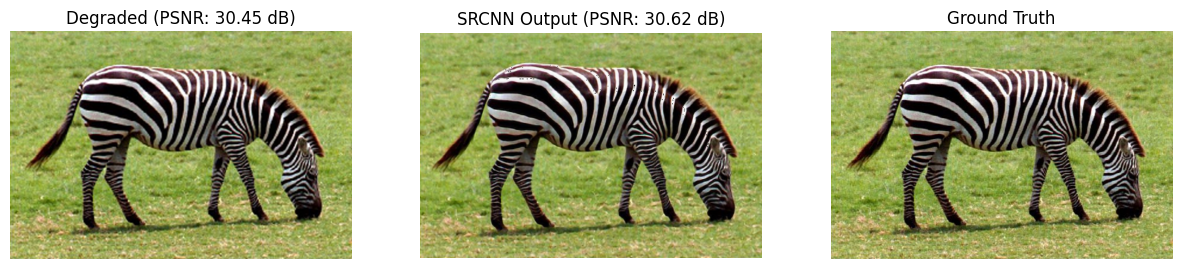

In [27]:
sample_image = "/kaggle/input/set-5-14-super-resolution-dataset/Set14/Set14/zebra.png"
visualize_and_save_prediction(sample_image, test_model, scale=2, save_dir="/kaggle/working/results")
